<a href="https://colab.research.google.com/github/SNEHILPANDEY15/FDA-assignment-/blob/main/BDA_Snehil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark -q

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Instacart Retail Analysis") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [3]:
import os
import pandas as pd
from pyspark.sql.types import *

#Adding datasets
orders = spark.read.csv(
    "/content/drive/MyDrive/BDA DATASET/orders.csv",
    header=True,
    inferSchema=True
)

prior = spark.read.csv(
    "/content/drive/MyDrive/BDA DATASET/order_products__prior.csv",
    header=True,
    inferSchema=True
)

products = spark.read.csv(
    "/content/drive/MyDrive/BDA DATASET/products.csv",
    header=True,
    inferSchema=True
)

aisles = spark.read.csv(
    "/content/drive/MyDrive/BDA DATASET/aisles.csv",
    header=True,
    inferSchema=True
)

departments = spark.read.csv(
    "/content/drive/MyDrive/BDA DATASET/departments.csv",
    header=True,
    inferSchema=True
)

train = spark.read.csv(
    "/content/drive/MyDrive/BDA DATASET/order_products__train.csv",
    header=True,
    inferSchema=True
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [4]:
print("Orders:", orders.count())
print("Prior Orders:", prior.count())
print("Products:", products.count())
print("Aisles:", aisles.count())
print("Departments:", departments.count())

Orders: 3421083
Prior Orders: 32434489
Products: 49688
Aisles: 134
Departments: 21


In [5]:
orders.printSchema()

products.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)



In [6]:
products.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)



In [7]:
aisles.printSchema()

root
 |-- aisle_id: integer (nullable = true)
 |-- aisle: string (nullable = true)



In [8]:
departments.printSchema()

root
 |-- department_id: integer (nullable = true)
 |-- department: string (nullable = true)



In [9]:
products.show(5, False)

+----------+-----------------------------------------------------------------+--------+-------------+
|product_id|product_name                                                     |aisle_id|department_id|
+----------+-----------------------------------------------------------------+--------+-------------+
|1         |Chocolate Sandwich Cookies                                       |61      |19           |
|2         |All-Seasons Salt                                                 |104     |13           |
|3         |Robust Golden Unsweetened Oolong Tea                             |94      |7            |
|4         |Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce|38      |1            |
|5         |Green Chile Anytime Sauce                                        |5       |13           |
+----------+-----------------------------------------------------------------+--------+-------------+
only showing top 5 rows


In [10]:
orders.show(5, False)


+--------+-------+--------+------------+---------+-----------------+----------------------+
|order_id|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|
+--------+-------+--------+------------+---------+-----------------+----------------------+
|2539329 |1      |prior   |1           |2        |8                |NULL                  |
|2398795 |1      |prior   |2           |3        |7                |15.0                  |
|473747  |1      |prior   |3           |3        |12               |21.0                  |
|2254736 |1      |prior   |4           |4        |7                |29.0                  |
|431534  |1      |prior   |5           |4        |15               |28.0                  |
+--------+-------+--------+------------+---------+-----------------+----------------------+
only showing top 5 rows


In [11]:
aisles.show(10, False)


+--------+--------------------------+
|aisle_id|aisle                     |
+--------+--------------------------+
|1       |prepared soups salads     |
|2       |specialty cheeses         |
|3       |energy granola bars       |
|4       |instant foods             |
|5       |marinades meat preparation|
|6       |other                     |
|7       |packaged meat             |
|8       |bakery desserts           |
|9       |pasta sauce               |
|10      |kitchen supplies          |
+--------+--------------------------+
only showing top 10 rows


In [12]:
departments.show(10, False)

+-------------+---------------+
|department_id|department     |
+-------------+---------------+
|1            |frozen         |
|2            |other          |
|3            |bakery         |
|4            |produce        |
|5            |alcohol        |
|6            |international  |
|7            |beverages      |
|8            |pets           |
|9            |dry goods pasta|
|10           |bulk           |
+-------------+---------------+
only showing top 10 rows


In [13]:
prior.show(10, False)

+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+---------+
|2       |33120     |1                |1        |
|2       |28985     |2                |1        |
|2       |9327      |3                |0        |
|2       |45918     |4                |1        |
|2       |30035     |5                |0        |
|2       |17794     |6                |1        |
|2       |40141     |7                |1        |
|2       |1819      |8                |1        |
|2       |43668     |9                |0        |
|3       |33754     |1                |1        |
+--------+----------+-----------------+---------+
only showing top 10 rows


In [14]:
train.show(10, False)

+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+---------+
|1       |49302     |1                |1        |
|1       |11109     |2                |1        |
|1       |10246     |3                |0        |
|1       |49683     |4                |0        |
|1       |43633     |5                |1        |
|1       |13176     |6                |0        |
|1       |47209     |7                |0        |
|1       |22035     |8                |1        |
|36      |39612     |1                |0        |
|36      |19660     |2                |1        |
+--------+----------+-----------------+---------+
only showing top 10 rows


In [15]:
products.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)



In [16]:
test1 = prior.join(products, "product_id")

print(test1.count())

32434489


In [17]:
instacart = orders.join(prior, "order_id").join(products, "product_id")

In [18]:
instacart.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)



In [19]:
files = [
    "/content/drive/MyDrive/BDA DATASET/orders.csv",
    "/content/drive/MyDrive/BDA DATASET/order_products__prior.csv",
    "/content/drive/MyDrive/BDA DATASET/products.csv",
    "/content/drive/MyDrive/BDA DATASET/aisles.csv",
    "/content/drive/MyDrive/BDA DATASET/departments.csv"
]

total_size = 0

for f in files:
    size = os.path.getsize(f)
    total_size += size
    print(os.path.basename(f), round(size/(1024*1024),2), "MB")

print("Total Size:", round(total_size/(1024*1024),2), "MB")
print("Estimated HDFS Blocks:", round(total_size/(128*1024*1024),2))

orders.csv 103.92 MB
order_products__prior.csv 550.8 MB
products.csv 2.07 MB
aisles.csv 0.0 MB
departments.csv 0.0 MB
Total Size: 656.79 MB
Estimated HDFS Blocks: 5.13


In [20]:
from pyspark.sql.functions import collect_set

basket_data = (
    instacart
    .groupBy("order_id")
    .agg(
        collect_set("product_name").alias("items")
    )
)

basket_data.show(10, truncate=False)

+--------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|order_id|items                                                                                                                                                                                                                                                                                                                                                  

In [22]:
print("Number of Orders:", basket_data.count())

Number of Orders: 3214874


In [23]:
basket_data.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- items: array (nullable = false)
 |    |-- element: string (containsNull = false)



In [25]:
basket_sample = basket_data.sample(
    fraction=0.05,
    seed=42
)

print("Sample Orders:", basket_sample.count())

Sample Orders: 160502


In [47]:
basket_sample = basket_data.sample(
    fraction=0.01,
    seed=42
)


from pyspark.ml.fpm import FPGrowth

fpGrowth = FPGrowth(
    itemsCol="items",
    minSupport=0.005,
    minConfidence=0.1
)

model = fpGrowth.fit(basket_sample)

print("Model training completed!")

Model training completed!


In [38]:
from pyspark.sql.functions import desc

rules = model.associationRules

print("Total Rules:", rules.count())

rules.sort(
    desc("confidence")
).show(20, False)

Total Rules: 107
+--------------------------------------+----------------------------+-------------------+------------------+---------------------+
|antecedent                            |consequent                  |confidence         |lift              |support              |
+--------------------------------------+----------------------------+-------------------+------------------+---------------------+
|[Organic Fuji Apple]                  |[Banana]                    |0.3797606093579978 |2.581907555671028 |0.010827412899823162 |
|[Honeycrisp Apple]                    |[Banana]                    |0.35096774193548386|2.386151281545339 |0.008438556758601433 |
|[Cucumber Kirby]                      |[Banana]                    |0.3372591006423983 |2.2929492915010385|0.009772593304997983 |
|[Lime Sparkling Water]                |[Sparkling Water Grapefruit]|0.32665330661322645|13.01485294445504 |0.005056929234014829 |
|[Organic Large Extra Fancy Fuji Apple]|[Bag of Organic Bananas]  

In [27]:
from pyspark.sql.functions import desc

frequent_itemsets = model.freqItemsets

frequent_itemsets \
    .sort(desc("freq")) \
    .limit(20) \
    .show(truncate=False)

+--------------------------+-----+
|items                     |freq |
+--------------------------+-----+
|[Banana]                  |23650|
|[Bag of Organic Bananas]  |19155|
|[Organic Strawberries]    |13419|
|[Organic Baby Spinach]    |12043|
|[Organic Hass Avocado]    |10788|
|[Organic Avocado]         |8748 |
|[Large Lemon]             |7770 |
|[Strawberries]            |7220 |
|[Limes]                   |6923 |
|[Organic Whole Milk]      |6898 |
|[Organic Raspberries]     |6854 |
|[Organic Yellow Onion]    |5642 |
|[Organic Zucchini]        |5349 |
|[Organic Garlic]          |5310 |
|[Organic Blueberries]     |5158 |
|[Cucumber Kirby]          |4719 |
|[Organic Fuji Apple]      |4473 |
|[Organic Lemon]           |4350 |
|[Apple Honeycrisp Organic]|4309 |
|[Organic Grape Tomatoes]  |4219 |
+--------------------------+-----+



In [44]:
rules = model.associationRules

rules \
    .sort(desc("confidence")) \
    .limit(20) \
    .show(truncate=False)

+--------------------------------------+----------------------------+-------------------+------------------+---------------------+
|antecedent                            |consequent                  |confidence         |lift              |support              |
+--------------------------------------+----------------------------+-------------------+------------------+---------------------+
|[Organic Fuji Apple]                  |[Banana]                    |0.3797606093579978 |2.581907555671028 |0.010827412899823162 |
|[Honeycrisp Apple]                    |[Banana]                    |0.35096774193548386|2.386151281545339 |0.008438556758601433 |
|[Cucumber Kirby]                      |[Banana]                    |0.3372591006423983 |2.2929492915010385|0.009772593304997983 |
|[Lime Sparkling Water]                |[Sparkling Water Grapefruit]|0.32665330661322645|13.01485294445504 |0.005056929234014829 |
|[Organic Large Extra Fancy Fuji Apple]|[Bag of Organic Bananas]    |0.309139784946

In [43]:
print("Total Frequent Itemsets:",
      frequent_itemsets.count())

print("Total Association Rules:",
      rules.count())

Total Frequent Itemsets: 118
Total Association Rules: 107


In [40]:
top_rules = (
    rules
    .sort(desc("confidence"))
    .limit(10)
)

top_rules.show(truncate=False)

+--------------------------------------+----------------------------+-------------------+------------------+--------------------+
|antecedent                            |consequent                  |confidence         |lift              |support             |
+--------------------------------------+----------------------------+-------------------+------------------+--------------------+
|[Organic Fuji Apple]                  |[Banana]                    |0.3797606093579978 |2.581907555671028 |0.010827412899823162|
|[Honeycrisp Apple]                    |[Banana]                    |0.35096774193548386|2.386151281545339 |0.008438556758601433|
|[Cucumber Kirby]                      |[Banana]                    |0.3372591006423983 |2.2929492915010385|0.009772593304997983|
|[Lime Sparkling Water]                |[Sparkling Water Grapefruit]|0.32665330661322645|13.01485294445504 |0.005056929234014829|
|[Organic Large Extra Fancy Fuji Apple]|[Bag of Organic Bananas]    |0.30913978494623656|2

In [41]:
pdf = top_rules.toPandas()

pdf.head()

,antecedent,consequent,confidence,lift,support
0,[Organic Fuji Apple],[Banana],0.379761,2.581908,0.010827
1,[Honeycrisp Apple],[Banana],0.350968,2.386151,0.008439
2,[Cucumber Kirby],[Banana],0.337259,2.292949,0.009773
3,[Lime Sparkling Water],[Sparkling Water Grapefruit],0.326653,13.014853,0.005057
4,[Organic Large Extra Fancy Fuji Apple],[Bag of Organic Bananas],0.309140,2.576138,0.007136


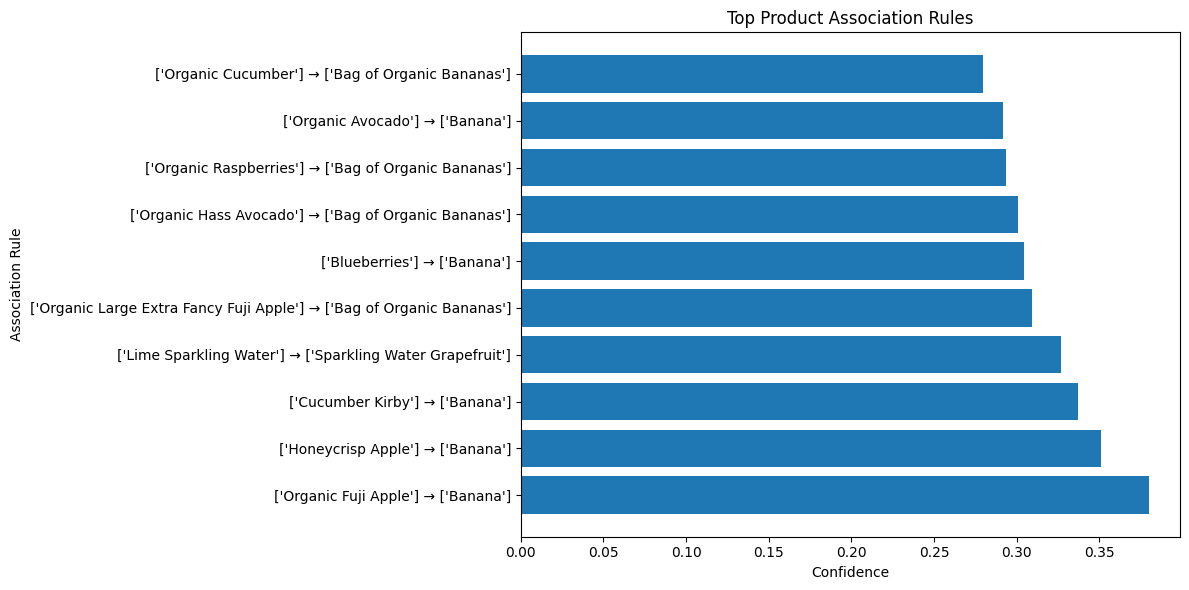

In [42]:
import matplotlib.pyplot as plt

pdf["rule"] = (
    pdf["antecedent"].astype(str)
    + " → " +
    pdf["consequent"].astype(str)
)

plt.figure(figsize=(12,6))

plt.barh(
    pdf["rule"],
    pdf["confidence"]
)

plt.xlabel("Confidence")
plt.ylabel("Association Rule")
plt.title("Top Product Association Rules")

plt.tight_layout()
plt.show()

In [33]:
model = fpGrowth.fit(basket_sample)

In [45]:
from pyspark.sql.functions import desc

top_products = (
    instacart
    .groupBy("product_name")
    .count()
    .sort(desc("count"))
    .limit(10)
)

top_products.show()

+--------------------+------+
|        product_name| count|
+--------------------+------+
|              Banana|472565|
|Bag of Organic Ba...|379450|
|Organic Strawberries|264683|
|Organic Baby Spinach|241921|
|Organic Hass Avocado|213584|
|     Organic Avocado|176815|
|         Large Lemon|152657|
|        Strawberries|142951|
|               Limes|140627|
|  Organic Whole Milk|137905|
+--------------------+------+



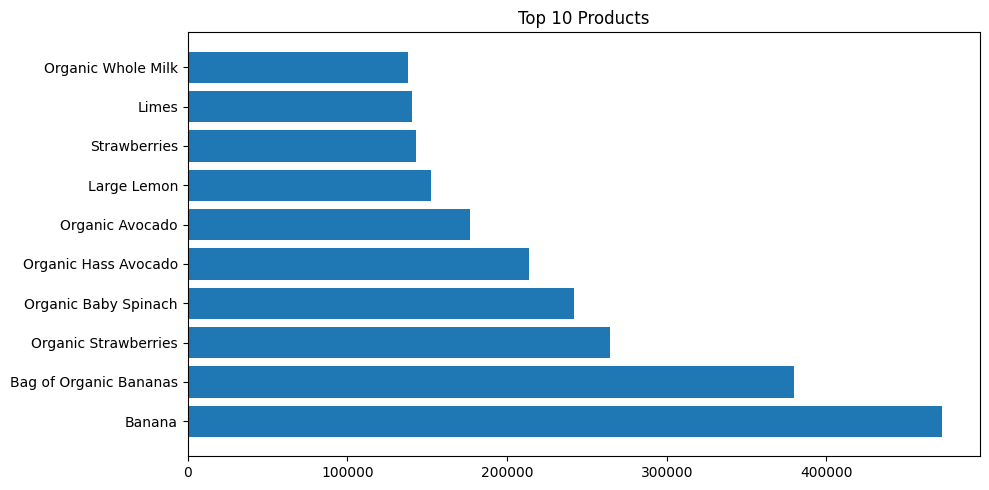

In [46]:
pdf2 = top_products.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(pdf2["product_name"], pdf2["count"])
plt.title("Top 10 Products")
plt.tight_layout()
plt.show()